Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 13,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. While some factors are intuitively understood (e.g., low grades), the relative importance and interaction of various predictors—such as financial stress (tuition vs. loans), academic preparation (High School Grade vs. University GPA), program characteristics (type, level), and student engagement (attendance, extracurricular participation)—are not clearly defined for this specific population.
Specifically, the dataset allows us to investigate key questions that are currently unanswered:
•What is the primary driver of dropout: pre-university academic preparedness (High School Grade), current academic performance (University GPA), or financial constraints (tuition fees, loan availability)?
•How do financial factors (e.g., Tuition_Fees, Student_Loan amount, Scholarship status) interact with academic factors to influence dropout risk?
•Does the impact of these factors vary significantly by student demographics (e.g., Gender, County), the program of study (Program, Program_Level), or levels of engagement (Attendance_Rate, Extracurricular_Participation)?
•Can a predictive model be built to identify students at high risk of dropping out before it happens, based on their first-year or pre-enrollment data?

3. Data Suitability
The provided dataset is well-structured for addressing this problem. It contains:
•Target Variable: A clear binary outcome variable (Dropout), where 1 indicates a student dropped out and 0 indicates they persisted.
•Predictor Variables: A wide range of potential predictors, including:
•Academic: High_School_Grade, University_GPA
•Financial: Scholarship (binary), Tuition_Fees, Student_Loan
•Demographic: Age, Gender, County
•Institutional: Program (e.g., Law, Engineering), Program_Level (e.g., Undergraduate, Postgraduate)
•Engagement: Attendance_Rate (%), Extracurricular_Participation (binary)
•Family Background: Parental_Education_Level
•Scale & Completeness: With over 13,000 records, the dataset has sufficient statistical power to detect meaningful patterns. However, a preliminary check for missing or inconsistent data is necessary before analysis.

4. Objectives of the Analysis
The primary objective is to identify, quantify, and model the key determinants of student dropout in this Kenyan higher education dataset. Specific sub-objectives include:
1.Descriptive Analysis: To profile the student population and compare the characteristics of those who dropped out versus those who persisted, across all academic, financial, demographic, and engagement variables.
2.Exploratory Factor Analysis: To investigate the relationship between independent variables (e.g., Tuition Fees and Student Loan) and the dependent variable (Dropout), and to explore correlations between predictors (e.g., High_School_Grade and University_GPA).
3.Predictive Modeling: To develop and evaluate a classification model (e.g., Logistic Regression, Random Forest, XGBoost) that can accurately predict a student's risk of dropping out based on available data. Feature importance from this model will reveal the most influential factors.
4.Actionable Insights Generation: To translate the findings from the analysis and model into clear, actionable recommendations for university administrators and policymakers. This includes identifying which student segments are most at risk and suggesting targeted interventions (e.g., financial aid restructuring, academic support programs, or engagement initiatives).

5. Expected Outcomes & Impact
A successful analysis will produce:
•A ranked list of the most significant predictors of student dropout in this context.
•A validated predictive model for early identification of at-risk students.
•Data-driven policy recommendations to reduce dropout rates, improve student retention, and optimize the allocation of institutional resources (e.g., targeting financial aid or tutoring to those who need it most).
Ultimately, this analysis aims to contribute to a more efficient and equitable higher education system in Kenya, ensuring that more students who enroll are able to successfully complete their chosen programs.

In [27]:
# Importing the necessary libraries for the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')


In [9]:
# Loading the dataset
School_df = pd.read_csv("student.csv")
School_df.head(50)

<ipython-input-9-f6609a7f3b5c>:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  School_df = pd.read_csv("student.csv")


,Gender,Birthdate,PHYSICALLYCHALLENGED,County,Loan_serial_number,ScholarshipApplied,InstitutionCode,InstitutionName,COURSECODE,ProgramCost,...,Category,applicanttype,LoanStatus,Unnamed: 21,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,0,MIGORI,2510374563,0,KPU,TECHNICAL UNIVERSITY OF KENYA,EEEI,270000.0,...,PublicUniversityGovtSponsored,1,Partially Disbursed,NaN,69,64,Primary,Primary,Primary,0
1,Male,08/07/1982,0,NaN,2510057518,0,CA,Catholic University,BED,160000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,63,65,Diploma,Secondary,Diploma,1
2,Male,18/02/1993,0,NaN,2510233585,0,MTK,Mount Kenya University,BBIT,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,57,Primary,Secondary,Secondary,0
3,Male,18/03/1986,0,NaN,2510031694,0,KAFUCO,Kaimosi Friends University,HNR,275400.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,51,76,Diploma,Primary,Diploma,0
4,Male,31/10/1987,0,NAKURU,2510438107,0,UBG,Bugema University,BHT,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,58,64,Secondary,Secondary,Secondary,0
5,Male,10/10/1987,0,NaN,2510215037,0,WU,Masinde Muliro University Of Science And Techn...,ECE,0.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,62,62,Secondary,Primary,Secondary,0
6,Male,14/05/1996,0,BUNGOMA,2510014065,0,MTK,Mount Kenya University,1279MTK4,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,64,66,Artisan,Secondary,Artisan,0
7,Female,24/04/1994,0,BUSIA,2510223680,0,MTK,Mount Kenya University,EDA,105000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,64,Degree,Secondary,Degree,1
8,Male,01/01/1996,0,NaN,2510000230,0,NU,University of Nairobi,C01,160653.0,...,PublicUniversitySelfSponsored,1,Partially Disbursed,NaN,76,88,Primary,Primary,Primary,0
9,Male,01/01/1996,0,NaN,2510010517,0,MTK,Mount Kenya University,BECD,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,65,70,Primary,NaN,Primary,0


In [10]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                62659 non-null   object 
 1   Birthdate             118259 non-null  object 
 2   PHYSICALLYCHALLENGED  118259 non-null  int64  
 3   County                118235 non-null  object 
 4   Loan_serial_number    118259 non-null  int64  
 5   ScholarshipApplied    118259 non-null  int64  
 6   InstitutionCode       118259 non-null  object 
 7   InstitutionName       118259 non-null  object 
 8   COURSECODE            117794 non-null  object 
 9   ProgramCost           117794 non-null  float64
 10  CourseCategory        114059 non-null  object 
 11  Adm No                118233 non-null  object 
 12  ExamYear              118259 non-null  int64  
 13  INDEXNUMBER           118258 non-null  object 
 14  TotalLoanAllocated    118259 non-null  float64
 15  

In [11]:
School_df.isna().sum()

Gender                   55600
Birthdate                    0
PHYSICALLYCHALLENGED         0
County                      24
Loan_serial_number           0
ScholarshipApplied           0
InstitutionCode              0
InstitutionName              0
COURSECODE                 465
ProgramCost                465
CourseCategory            4200
Adm No                      26
ExamYear                     0
INDEXNUMBER                  1
TotalLoanAllocated           0
LoanproductCode              0
BursaryAllocated             0
BURSARYBATCHNUMBER      118259
Category                     0
applicanttype                0
LoanStatus                   3
Unnamed: 21             118259
Mother_Age                   0
Father_Age                   0
Father_educ_level        16817
Mother_educ_level        20568
Highest_educ_level       13548
Drop_out                     0
dtype: int64

In [12]:
columns_to_drop = ['BURSARYBATCHNUMBER', 'Unnamed: 21', 'Father_educ_level', 'Mother_educ_level', 'COURSECODE']

# Use axis=1 to tell pandas these are column names, not row indexes
School_df = School_df.drop(columns_to_drop, axis=1)

In [13]:
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'Category', 'LoanStatus', 'Mother_Age',
       'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out'],
      dtype='object')

In [15]:
#After careful evaluation, we decided to drop the rows in the columns with missing values

School_df=School_df.dropna(subset=["Gender","County","ProgramCost","CourseCategory",
                                   "Father_educ_level","Mother_educ_level","LoanStatus","Highest_educ_level"])
School_df.head()

,Gender,Birthdate,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,Category,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.0,PublicUniversityGovtSponsored,Partially Disbursed,69,64,Primary,Primary,Primary,0
4,Male,31/10/1987,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.0,PrivateUniversitySelfSponsored,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0
6,Male,14/05/1996,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.0,PrivateUniversitySelfSponsored,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0
7,Female,24/04/1994,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.0,PrivateUniversitySelfSponsored,Partially Disbursed,54,64,Degree,Secondary,Degree,1
10,Male,07/07/1988,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.0,PrivateUniversitySelfSponsored,Partially Disbursed,56,62,Secondary,Primary,Secondary,1


In [16]:
#checking for the missing values in the df

School_df.isna().sum()

Gender                0
Birthdate             0
County                0
ScholarshipApplied    0
InstitutionName       0
ProgramCost           0
CourseCategory        0
ExamYear              0
TotalLoanAllocated    0
Category              0
LoanStatus            0
Mother_Age            0
Father_Age            0
Father_educ_level     0
Mother_educ_level     0
Highest_educ_level    0
Drop_out              0
dtype: int64

In [18]:
School_df.describe()

,ScholarshipApplied,ProgramCost,ExamYear,TotalLoanAllocated,Mother_Age,Father_Age,Drop_out
count,47653.000000,47653.000000,47653.000000,47653.000000,47653.000000,47653.000000,47653.000000
mean,0.833966,216273.514553,2023.705076,146420.402595,45.852286,52.133801,0.300506
std,0.372115,80670.984957,1.236198,39890.705704,7.451715,8.555153,0.458483
min,0.000000,0.000000,1993.000000,24700.000000,19.000000,20.000000,0.000000
25%,1.000000,183600.000000,2024.000000,127337.160000,40.000000,47.000000,0.000000
50%,1.000000,206635.000000,2024.000000,150463.020000,45.000000,52.000000,0.000000
75%,1.000000,270000.000000,2024.000000,174638.405400,51.000000,57.000000,1.000000
max,1.000000,720000.000000,2024.000000,347992.910000,157.000000,158.000000,1.000000


In [17]:
School_df.shape

(47653, 17)

### Creating some new features in the df

In [ ]:
# Creating the Age column

# convert to datetime
School_df["Birthdate"] = pd.to_datetime(School_df["Birthdate"], errors="coerce")

# today's date
today = datetime.today()

# create age column
School_df["age"] = School_df["Birthdate"].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
    if pd.notnull(x) else None
)

In [22]:
School_df.head(50)

,Gender,Birthdate,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,Category,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out,age
0,Male,1996-03-13,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.000,PublicUniversityGovtSponsored,Partially Disbursed,69,64,Primary,Primary,Primary,0,30.0
4,Male,1987-10-31,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.000,PrivateUniversitySelfSponsored,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0,38.0
6,Male,1996-05-14,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.000,PrivateUniversitySelfSponsored,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0,29.0
7,Female,1994-04-24,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.000,PrivateUniversitySelfSponsored,Partially Disbursed,54,64,Degree,Secondary,Degree,1,31.0
10,Male,1988-07-07,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.000,PrivateUniversitySelfSponsored,Partially Disbursed,56,62,Secondary,Primary,Secondary,1,37.0
13,Male,1992-09-15,NAIROBI,0,Open University of Kenya,105000.0,Humanity,2011,55000.000,PublicUniversitySelfSponsored,Partially Disbursed,63,61,Secondary,Primary,Secondary,0,33.0
16,Female,1988-07-07,MAKUENI,0,Mount Kenya University,140000.0,LaboratoryTechnology,2013,50000.000,PrivateUniversitySelfSponsored,Partially Disbursed,56,63,Primary,Secondary,Secondary,0,37.0
17,Male,1991-10-01,HOMA BAY,0,Mount Kenya University,110000.0,HealthRecordsMgt,2010,50000.000,PrivateUniversitySelfSponsored,Partially Disbursed,50,67,Secondary,Secondary,Secondary,1,34.0
19,Male,1996-05-28,HOMA BAY,0,Mount Kenya University,110000.0,Education,2014,50000.000,PrivateUniversityGovtSponsored,Partially Disbursed,55,65,Primary,Primary,Primary,0,29.0
22,Male,1996-11-11,NYAMIRA,0,Mount Kenya University,111000.0,Humanity,2014,55000.000,PrivateUniversitySelfSponsored,Partially Disbursed,48,55,Secondary,Primary,Secondary,0,29.0


In [28]:
# 

School_df[['UniversityType', 'Sponsored']] = School_df['Category'].str.extract(
    r'^(Public|Private).*?(GovtSponsored|SelfSponsored)$'
)
School_df.head(10)

,Gender,Birthdate,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,Category,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out,age,UniversityType,Sponsored
0,Male,1996-03-13,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.0,PublicUniversityGovtSponsored,Partially Disbursed,69,64,Primary,Primary,Primary,0,30.0,Public,GovtSponsored
4,Male,1987-10-31,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.0,PrivateUniversitySelfSponsored,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0,38.0,Private,SelfSponsored
6,Male,1996-05-14,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.0,PrivateUniversitySelfSponsored,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0,29.0,Private,SelfSponsored
7,Female,1994-04-24,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.0,PrivateUniversitySelfSponsored,Partially Disbursed,54,64,Degree,Secondary,Degree,1,31.0,Private,SelfSponsored
10,Male,1988-07-07,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.0,PrivateUniversitySelfSponsored,Partially Disbursed,56,62,Secondary,Primary,Secondary,1,37.0,Private,SelfSponsored
13,Male,1992-09-15,NAIROBI,0,Open University of Kenya,105000.0,Humanity,2011,55000.0,PublicUniversitySelfSponsored,Partially Disbursed,63,61,Secondary,Primary,Secondary,0,33.0,Public,SelfSponsored
16,Female,1988-07-07,MAKUENI,0,Mount Kenya University,140000.0,LaboratoryTechnology,2013,50000.0,PrivateUniversitySelfSponsored,Partially Disbursed,56,63,Primary,Secondary,Secondary,0,37.0,Private,SelfSponsored
17,Male,1991-10-01,HOMA BAY,0,Mount Kenya University,110000.0,HealthRecordsMgt,2010,50000.0,PrivateUniversitySelfSponsored,Partially Disbursed,50,67,Secondary,Secondary,Secondary,1,34.0,Private,SelfSponsored
19,Male,1996-05-28,HOMA BAY,0,Mount Kenya University,110000.0,Education,2014,50000.0,PrivateUniversityGovtSponsored,Partially Disbursed,55,65,Primary,Primary,Primary,0,29.0,Private,GovtSponsored
22,Male,1996-11-11,NYAMIRA,0,Mount Kenya University,111000.0,Humanity,2014,55000.0,PrivateUniversitySelfSponsored,Partially Disbursed,48,55,Secondary,Primary,Secondary,0,29.0,Private,SelfSponsored


In [23]:
School_df.corr()

,ScholarshipApplied,ProgramCost,ExamYear,TotalLoanAllocated,Mother_Age,Father_Age,Drop_out,age
ScholarshipApplied,1.000000,0.139192,0.459919,0.507426,-0.100986,-0.047550,0.002288,-0.241708
ProgramCost,0.139192,1.000000,0.099668,0.552677,0.000525,-0.011513,-0.005568,-0.128039
ExamYear,0.459919,0.099668,1.000000,0.457502,-0.158964,-0.121653,0.001641,-0.615593
TotalLoanAllocated,0.507426,0.552677,0.457502,1.000000,-0.071333,-0.054889,-0.004032,-0.325679
Mother_Age,-0.100986,0.000525,-0.158964,-0.071333,1.000000,0.561468,0.003681,0.120188
Father_Age,-0.047550,-0.011513,-0.121653,-0.054889,0.561468,1.000000,0.003547,0.127075
Drop_out,0.002288,-0.005568,0.001641,-0.004032,0.003681,0.003547,1.000000,-0.000447
age,-0.241708,-0.128039,-0.615593,-0.325679,0.120188,0.127075,-0.000447,1.000000


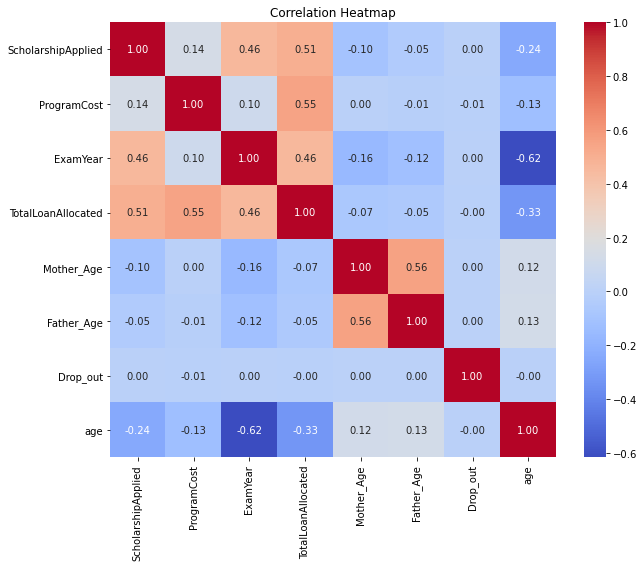

In [24]:
corr = School_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Creating the parent education gap column

School_df[]

SyntaxError: invalid syntax (<ipython-input-34-9399f6e18c3a>, line 3)

In [ ]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53051 entries, 0 to 118258
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Gender                53051 non-null  object        
 1   Birthdate             53044 non-null  datetime64[ns]
 2   PHYSICALLYCHALLENGED  53051 non-null  int64         
 3   County                53051 non-null  object        
 4   Loan_serial_number    53051 non-null  int64         
 5   ScholarshipApplied    53051 non-null  int64         
 6   InstitutionCode       53051 non-null  object        
 7   InstitutionName       53051 non-null  object        
 8   COURSECODE            53051 non-null  object        
 9   ProgramCost           53051 non-null  float64       
 10  CourseCategory        53051 non-null  object        
 11  Adm No                53051 non-null  object        
 12  ExamYear              53051 non-null  int64         
 13  INDEXNUMBER    

In [ ]:
School_df['Highest_educ_level'].value_counts()

Secondary      19843
Primary        18995
Diploma         5353
Degree          4328
Certificate     3149
Masters          740
Artisan          486
PhD              157
Name: Highest_educ_level, dtype: int64